# Trabajo Práctico Nº 3
## Transformaciones Homogéneas, SE(3) e Inversión Analítica



In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
np.set_printoptions(precision=10, suppress=True)

# 1. Clase Transform3D

Para una transformación homogénea:

\[
T=\begin{bmatrix}R&p\\0&1\end{bmatrix}
\]

su inversa analítica es:

\[
T^{-1}=\begin{bmatrix}R^T&-R^Tp\\0&1\end{bmatrix}
\]

In [5]:
class Transform3D:
    "Representa una transformación homogénea en SE(3)."

    def __init__(self, R, p):
        self.R = np.asarray(R, dtype=float)
        self.p = np.asarray(p, dtype=float).reshape(3)

        if self.R.shape != (3, 3):
            raise ValueError("R debe tener dimensiones 3x3.")

        self.T = np.eye(4)
        self.T[:3, :3] = self.R
        self.T[:3, 3] = self.p

    def inv_analytic(self):
        "Calcula T^-1 usando R^T y -R^T p."
        R_inv = self.R.T
        p_inv = -R_inv @ self.p

        T_inv = np.eye(4)
        T_inv[:3, :3] = R_inv
        T_inv[:3, 3] = p_inv
        return T_inv

    def inv_generic(self):
        "Calcula la inversa mediante NumPy."
        return np.linalg.inv(self.T)

    def transform_point(self, point):
        point = np.asarray(point, dtype=float).reshape(3)
        return self.R @ point + self.p

# 2. Transformación del Ejercicio 1

Se utiliza:

\[
R=
\begin{bmatrix}
1/2&0&\sqrt3/2\\
\sqrt3/2&0&-1/2\\
0&1&0
\end{bmatrix},
\qquad
p=
\begin{bmatrix}0.4\\-0.2\\0.1\end{bmatrix}
\]

In [6]:
sqrt3 = np.sqrt(3)

R = np.array([
    [0.5, 0.0, sqrt3/2],
    [sqrt3/2, 0.0, -0.5],
    [0.0, 1.0, 0.0]
])

p = np.array([0.4, -0.2, 0.1])

transform = Transform3D(R, p)

print("Matriz homogénea T:")
print(transform.T)

Matriz homogénea T:
[[ 0.5           0.            0.8660254038  0.4         ]
 [ 0.8660254038  0.           -0.5          -0.2         ]
 [ 0.            1.            0.            0.1         ]
 [ 0.            0.            0.            1.          ]]


# 3. Inversa analítica y genérica

In [7]:
T_inv_analytic = transform.inv_analytic()
T_inv_generic = transform.inv_generic()

print("Inversa analítica:")
print(T_inv_analytic)

print("\nInversa genérica:")
print(T_inv_generic)

difference = T_inv_analytic - T_inv_generic
print("\nError entre ambas:")
print(np.linalg.norm(difference, ord='fro'))

Inversa analítica:
[[ 0.5           0.8660254038  0.           -0.0267949192]
 [ 0.            0.            1.           -0.1         ]
 [ 0.8660254038 -0.5           0.           -0.4464101615]
 [ 0.            0.            0.            1.          ]]

Inversa genérica:
[[ 0.5           0.8660254038  0.           -0.0267949192]
 [ 0.            0.            1.           -0.1         ]
 [ 0.8660254038 -0.5           0.           -0.4464101615]
 [ 0.            0.            0.            1.          ]]

Error entre ambas:
3.1592929488711313e-16


# 4. Validación de la inversa

Se evalúa:

\[
E=T T^{-1}-I
\]

La guía exige:

\[
\|E\|_F<10^{-14}
\]

In [8]:
E = transform.T @ T_inv_analytic - np.eye(4)
error_frobenius = np.linalg.norm(E, ord='fro')

print("Matriz E:")
print(E)
print(f"\nNorma de Frobenius: {error_frobenius:.18e}")

if error_frobenius < 1e-14:
    print("VALIDACIÓN EXITOSA: ||E||_F < 1e-14")
else:
    print("No se alcanzó el umbral solicitado.")

Matriz E:
[[-0.  0.  0.  0.]
 [ 0. -0.  0. -0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

Norma de Frobenius: 1.688305753616064869e-16
VALIDACIÓN EXITOSA: ||E||_F < 1e-14


# 5. Transformación del punto del Ejercicio 1

In [9]:
p_B = np.array([0.05, 0.10, 0.0])
p_A = transform.transform_point(p_B)

print("p_B =", p_B)
print("p_A =", p_A)
print("Resultado esperado aproximado: [0.425, -0.15669873, 0.2]")

p_B = [0.05 0.1  0.  ]
p_A = [ 0.425        -0.1566987298  0.2         ]
Resultado esperado aproximado: [0.425, -0.15669873, 0.2]


# 6. Benchmark temporal

Se comparan 100 000 inversiones analíticas contra 100 000 inversiones genéricas utilizando `time.perf_counter()`.

In [10]:
N = 100_000

# Calentamiento
for _ in range(100):
    transform.inv_analytic()
    transform.inv_generic()

start = time.perf_counter()
for _ in range(N):
    transform.inv_analytic()
time_analytic = time.perf_counter() - start

start = time.perf_counter()
for _ in range(N):
    transform.inv_generic()
time_generic = time.perf_counter() - start

reduction = (1 - time_analytic / time_generic) * 100

print(f"Tiempo analítico: {time_analytic:.6f} s")
print(f"Tiempo genérico:  {time_generic:.6f} s")
print(f"Reducción porcentual: {reduction:.2f}%")

Tiempo analítico: 0.597472 s
Tiempo genérico:  0.698601 s
Reducción porcentual: 14.48%


# 7. Gráfica de comparación

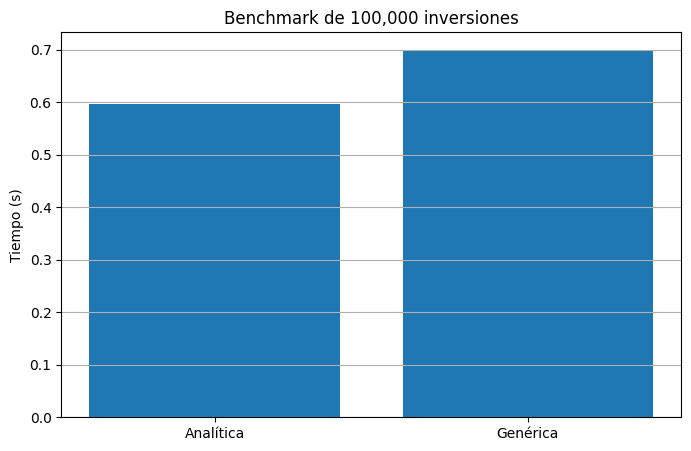

In [11]:
methods = ["Analítica", "Genérica"]
times = [time_analytic, time_generic]

plt.figure(figsize=(8,5))
plt.bar(methods, times)
plt.ylabel("Tiempo (s)")
plt.title(f"Benchmark de {N:,} inversiones")
plt.grid(axis="y")
plt.show()

# Conclusiones

- La clase `Transform3D` permite construir transformaciones homogéneas de tamaño 4×4.
- La inversión analítica utiliza la estructura particular de SE(3), usando \(R^T\) y \(-R^Tp\).
- La norma de Frobenius verifica cuantitativamente que \(TT^{-1}\) es aproximadamente la identidad.
- El benchmark compara el costo temporal de la inversión analítica frente a `np.linalg.inv()`.
- Los tiempos concretos pueden variar según el equipo y el entorno de ejecución.
